# TUTORIAL: ¿CÓMO MEDIR LA CALIDAD DE LOS PRONÓSTICOS EN SERIES DE TIEMPO?

En este tutorial vamos a ver cuáles son las métricas más usadas para medir la calidad de los pronósticos generados por un modelo predictivo en Series de Tiempo. Además veremos los pros y los contras de cada una de estas métricas y las sugerencias de uso

Contenido:
1. ¿Qué es la calidad de los pronósticos y para qué cuantificarla?
2. Las métricas de desempeño más usadas: RMSE, MAE y MAPE
3. ¿Cómo usar las métricas para medir el desempeño de un modelo?

## 1. ¿Qué es la calidad de los pronósticos y para qué cuantificarla?

- Cuando construimos un modelo predictivo para Series de Tiempo lo que nos interesa es saber qué tan buenos o qué tan malos son los pronósticos que genera
- Así que la idea es **cuantificar** de alguna manera el error en los pronósticos
- Si cuantificamos este error en los pronósticos podremos decidir:
    - Si el modelo que estamos implementando es adecuado
    - O si probamos varios modelos cuál de ellos será el más adecuado


Entendamos la idea básica de esta medición de desempeño. Comencemos leyendo el set de datos que contiene el registro histórico (diario) del comportamiento del valor de la acción de Apple durante los últimos años:

In [1]:
# Leer dataset
import pandas as pd
import numpy as np

df = pd.read_csv('accion_apple.csv', parse_dates=['ds'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   unique_id  2514 non-null   object        
 1   ds         2514 non-null   datetime64[ns]
 2   y          2514 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 59.1+ KB


In [2]:
!pip install prophet

In [3]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score

#X = df.drop(columns=["y","unique_id"])
#y = df["y"]

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42

train = df.iloc[:-365]   # todo menos el último año
test  = df.iloc[-365:]   # último año como prueba

#ridge = Ridge(alpha=10)  # prueba con alpha=1, 10, 100
#ridge.fit(X, y)
#y_pred = ridge.predict(X)
#fd['prons']=y_pred

from prophet import Prophet

m = Prophet()
m.fit(train.rename(columns={"ds": "ds", "y": "y"}))

future = m.make_future_dataframe(periods=len(test))
forecast = m.predict(future)
forecast

23:01:47 - cmdstanpy - INFO - Chain [1] start processing
23:01:47 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-07-01,24.685203,13.977047,34.049042,24.685203,24.685203,-0.860258,-0.860258,-0.860258,-0.623510,-0.623510,-0.623510,-0.236747,-0.236747,-0.236747,0.0,0.0,0.0,23.824945
1,2015-07-02,24.685417,14.349420,33.238960,24.685417,24.685417,-0.768959,-0.768959,-0.768959,-0.722004,-0.722004,-0.722004,-0.046955,-0.046955,-0.046955,0.0,0.0,0.0,23.916457
2,2015-07-06,24.686273,13.786660,34.305020,24.686273,24.686273,0.151171,0.151171,0.151171,-0.609111,-0.609111,-0.609111,0.760282,0.760282,0.760282,0.0,0.0,0.0,24.837444
3,2015-07-07,24.686487,14.898594,34.712150,24.686487,24.686487,0.298834,0.298834,0.298834,-0.668732,-0.668732,-0.668732,0.967566,0.967566,0.967566,0.0,0.0,0.0,24.985321
4,2015-07-08,24.686701,15.961347,34.911425,24.686701,24.686701,0.550696,0.550696,0.550696,-0.623510,-0.623510,-0.623510,1.174206,1.174206,1.174206,0.0,0.0,0.0,25.237397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509,2025-01-07,203.820100,183.691043,219.552275,188.681934,218.583739,-2.203459,-2.203459,-2.203459,-0.668732,-0.668732,-0.668732,-1.534727,-1.534727,-1.534727,0.0,0.0,0.0,201.616641
2510,2025-01-08,203.878931,183.159363,219.576066,188.655049,218.694340,-2.300030,-2.300030,-2.300030,-0.623510,-0.623510,-0.623510,-1.676520,-1.676520,-1.676520,0.0,0.0,0.0,201.578901
2511,2025-01-09,203.937763,183.739087,219.324948,188.621830,218.881528,-2.528612,-2.528612,-2.528612,-0.722004,-0.722004,-0.722004,-1.806608,-1.806608,-1.806608,0.0,0.0,0.0,201.409151
2512,2025-01-10,203.996594,182.793157,220.291107,188.589161,219.068715,-2.726125,-2.726125,-2.726125,-0.803458,-0.803458,-0.803458,-1.922668,-1.922668,-1.922668,0.0,0.0,0.0,201.270469


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = test["y"].values
y_pred = forecast.iloc[-len(test):]["yhat"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 21.58673944705374
RMSE: 26.33420656568944


/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


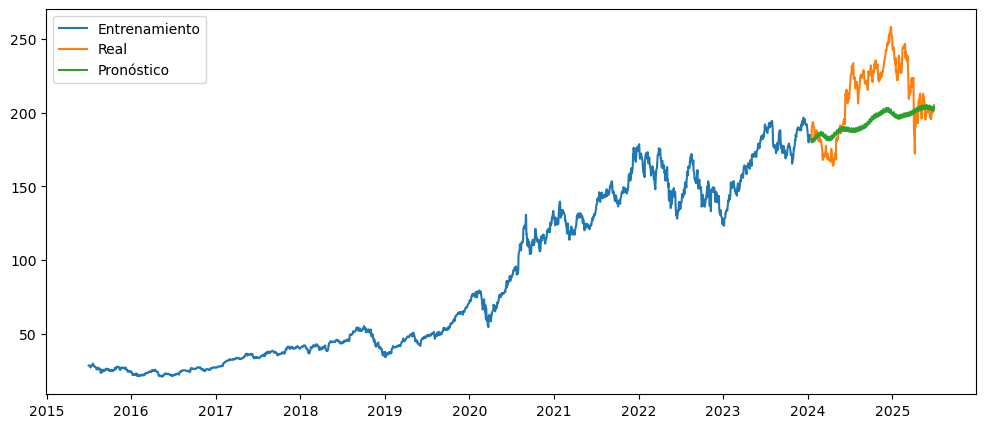

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train["ds"], train["y"], label="Entrenamiento")
plt.plot(test["ds"], test["y"], label="Real")
plt.plot(test["ds"], y_pred, label="Pronóstico")
plt.legend()
plt.show()


La columna "y" contiene los valores reales de la acción y la columna "prons" contiene los pronósticos realizados por un modelo.

Veamos gráficamente cómo se comparan los valores reales con los pronosticados:

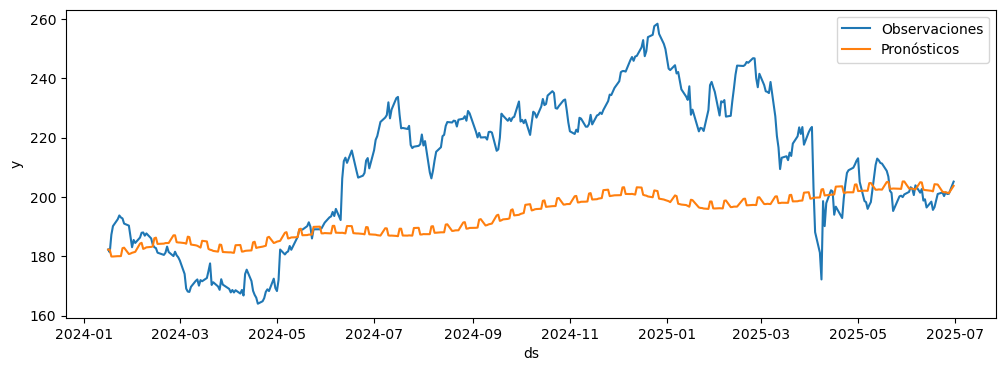

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
sns.lineplot(x=test["ds"], y=test["y"], label="Observaciones")
sns.lineplot(x=test["ds"], y=y_pred,  label="Pronósticos");

Vemos que:

- Los pronósticos siguen "bastante bien" el comportamiento de la Serie original
- Pero en algunos instantes de tiempo la predicción "no es tan buena" pues no logra capturar variaciones rápidas en la Serie original

La idea es que no seamos subjetivos al evaluar el desempeño del modelo y que usemos algunas métricas para cuantificar dicho desempeño.

## 2. Las métricas de desempeño más usadas: RMSE, MAE y MAPE

Aunque hay múltiples métricas, las más usadas son convencionalmente RMSE, MAE y MAPE.

Veamos en detalle cada una de estas métricas, así como su forma de cálculo y sus ventajas y desventajas.

### 2.1. Raíz cuadrada del error cuadrático medio (*RMSE: root mean squared error*)

Si $N$ es la cantidad de datos que tiene la Serie, $y_t$ es la observación (valor conocido) en cada instante de tiempo y $\hat{y}_t$ es el pronóstico correspondiente, entonces:

$$\text{RMSE} = \sqrt{\frac {\sum_{t=1}^{n} \left( y_t - \hat{y}_t \right)^2}{N}}$$

Algunas características, ventajas y desventajas de esta métrica:
- Es dependiente de la escala: **la métrica está en la misma escala de las observaciones originales**
- ✅ Es fácil de interpretar (precisamente porque está en la misma escala de los datos originales)
- ❌ Es sensible a valores extremos, pues el error cuadrático "amplifica" las diferencias (aunque esto puede ser visto como una ventaja)

Calculemos el RMSE para los pronósticos anteriores:

In [7]:
x=test["ds"]
y=test["y"]
y_pred=y_pred

mse=np.mean((y - y_pred)**2)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f} USD  (MSE: {mse:.2f} USD2)")

RMSE: 26.33 USD  (MSE: 693.49 USD2)


¿Este valor corresponde a un desempeño adecuado o no?

- Se debe comparar con el rango de valores de la Serie original:
    - Así, la Serie original tiene valores cercanos a los 225 USD y el error que se tiene en el pronóstico es del orden de 8.46.
    - Y por tanto este error representa aproximadamente un 3.8% de la escala original de la Serie
- Preguntas que deberíamos responder:
    - ¿Estamos dispuestos a aceptar un error de esta magnitud en nuestro proyecto?
    - ¿Existe algún modelo que genere un menor error?

### 2.2. Error absoluto medio (*MAE: mean absolute error*)

En este caso el error se calcula como:

$$\text{MAE} = \frac{\sum_{t=1}^{n} | y_t - \hat{y}_t |}{N}$$

Algunas características, ventajas y desventajas de esta métrica:
- Es dependiente de la escala: **la métrica está en la misma escala de las observaciones originales**
- ✅ Es fácil de interpretar (precisamente porque está en la misma escala de los datos originales)
- ✅ Es menos sensible a valores extremos en comparación con el RMSE (aunque esto puede ser visto como una desventaja)
    - ❌ Puede indicar un desempeño más optimista que el obtenido con el RMSE

Calculemos el MAE para los pronósticos anteriores:

In [8]:
mae = np.mean(np.abs(y - y_pred))
print(f"MAE: {mae:.2f} USD")

MAE: 21.59 USD


Recordemos que el RMSE fue de 8.46 USD. Esto se debe a que la primera métrica es sensible a valores extremos (los cuales están precisamente en la Serie original).

En este caso, estos 5.35 USD representan un 5.35/225 = 2.4% de la escala original de la Serie. De nuevo, debemos preguntarnos:

- ¿Estamos dispuestos a aceptar un error de esta magnitud en nuestro proyecto?
- ¿Existe algún modelo que genere un menor error?

### 2.3. Error porcentual absoluto medio (*MAPE: mean absolute percentage error*)

En este caso el error se calcula como:

$$\text{MAPE} = \frac{100}{n} \sum_{t=1}^{n} \left| \frac{y_t - \hat{y}_t}{y_t} \right|$$


Algunas características, ventajas y desventajas de esta métrica:
- Es **independiente de la escala: la métrica se mide como un porcentaje
- ✅ Es fácil de interpretar: 0% → mejor desempeño, 100% o más → desempeño "terrible"
- ✅ Es menos sensible a valores extremos en comparación con el RMSE
- ❌ No es adecuada si la serie original contiene valores iguales o muy cercanos a cero

Calculemos el MAPE para los pronósticos anteriores:

In [9]:
mape = np.mean(np.abs((y - y_pred) / y)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 9.75%


Lo cual quiere decir que, en promedio, el modelo genera pronósticos que se alejan en un 2.54% del valor real de la Serie.

Al igual que en los casos anteriores, debemos preguntarnos:

- ¿Estamos dispuestos a aceptar un error de esta magnitud en nuestro proyecto?
- ¿Existe algún modelo que genere un menor error?

# Para la Guía Autónoma

Desarrollar el modelamiento (y validación) con los datos de tu proyecto, en caso de no ser el tipo de objetivo/problema, debes desarrollar con un dataset de kaggle o de otra fuente. 
Seguir los pasos del cuaderno de la guía práctica pero usar otros datos o datos actualizados de
https://es.investing.com/equities/apple-computer-inc-historical-data 